# Radical Entry Rates At Finite Particle Concentrations

In [1]:
import pickle
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pyvista as pv
from numpy.typing import NDArray

from epentry import Box
from epentry.engine import simulate_multiple

pv.set_jupyter_backend('html') # 'trame' should work, but does not

## Preamble

**Note:** Most computationally-heavy methods are implemented using Numba. Compilation occurs the first time the method is called, so the first run always takes some time.

### Generate a Box with Particles

Initialize the box with the target parameters.

In [2]:
box = Box(
    rs=[500e-9, 200e-9, 100e-9],
    vfs=[0.10, 0.05, 0.01],
    Nt=1000,
)

In [3]:
box

Box(
    rs          = [5.e-07 2.e-07 1.e-07],
    vfs_target  = [0.1  0.05 0.01],
    vs          = [0. 0. 0.],
    Nt_target   = 1000,
    Nt          = 0,
    Ns          = [0 0 0],
    Lbox        = 0.0,
    success_rsa = False,
)

Then run random sequential addition (RSA) to place the particles.

In [4]:
box.rsa()

True

In [5]:
box

Box(
    rs          = [5.e-07 2.e-07 1.e-07],
    vfs_target  = [0.1  0.05 0.01],
    vs          = [0.10016875 0.0500588  0.0099913 ],
    Nt_target   = 1000,
    Nt          = 1000,
    Ns          = [ 47 367 586],
    Lbox        = 6.263081676156835e-06,
    success_rsa = True,
)

The matplotlib renderer produces static images.

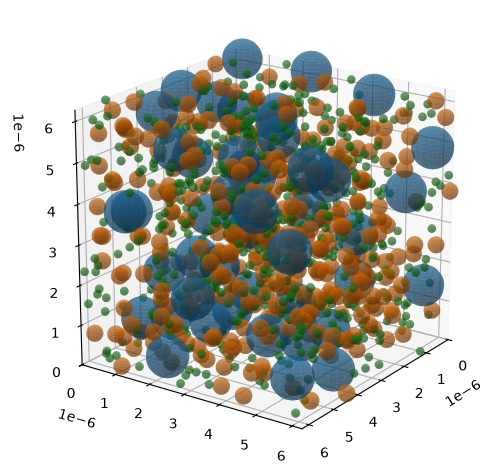

In [6]:
_ = box.plot(backend="matplotlib")

The pyvista renderer is much faster and is interactive.

In [7]:
plotter = box.plot()
plotter.show()

EmbeddableWidget(value='<iframe srcdoc="<!doctype html>\n<html lang=&quot;en&quot;>\n  <head>\n    <meta chars…

### Compute a Single Random Walk

In [8]:
walk = box.simulate_walk(D=1e-9)

In [9]:
walk.success

True

In [10]:
walk.time

4.402834813735155e-05

In [11]:
walk.trajectory.shape

(29, 3)

In [12]:
plotter = box.plot(walk=walk)
plotter.show()

EmbeddableWidget(value='<iframe srcdoc="<!doctype html>\n<html lang=&quot;en&quot;>\n  <head>\n    <meta chars…

## Simulations

A helper function to run a sequence of simulations at constant $r_i/r_j$ and $N_i/N_j$ over a range of $\phi_{\mathrm{p}}$.

In [13]:
def simulate_dispersion(
    rs: NDArray | list,
    ns: NDArray | list,
    vfp: NDArray | list,
    number_particles_per_box: int,
    number_boxes: int,
    number_walks_per_box: int,
    save_results: bool = True,
) -> dict:
    """
    Simulate random walks in multimodal systems across a range of total volume
    fractions.

    Parameters
    ----------
    rs : NDArray | list
        Array of particle radii to simulate.
    ns : NDArray | list
        Array of number fractions corresponding to the particle radii.
    vfp : NDArray | list
        Array of total volume fractions to simulate.
    number_particles_per_box : int
        Number of particles to place in each box.
    number_boxes : int
        Number of boxes to simulate for each volume fraction.
    number_walks_per_box : int
        Number of random walks to simulate in each box.
    save_results : bool
        Whether to save the results to a file.

    Returns
    -------
    dict
        A dictionary containing the input parameters and the results of the
        simulations, including the success, time, and group of each walk.
    """
    rs = np.asarray(rs)
    vfp = np.asarray(vfp)
    ns = np.asarray(ns)

    data = {
        "inputs": {
            "rs": rs,
            "ns": ns,
            "vfp": vfp,
            "number_particles_per_box": number_particles_per_box,
            "number_boxes": number_boxes,
            "number_walks_per_box": number_walks_per_box,
        },
        "results": [],
    }

    for i in range(len(vfp)):
        print(f"Volume fraction: {vfp[i]:.3f}", flush=True)

        vfs = ns * rs**3
        vfs *= vfp[i] / vfs.sum()
        walks = simulate_multiple(
            rs=rs,
            vfs=vfs,
            number_particles_per_box=number_particles_per_box,
            number_boxes=number_boxes,
            number_walks_per_box=number_walks_per_box,
        )

        result = {
            "rs": rs,
            "vfs": vfs,
            "walks": [
                {
                    "success": walk.success,
                    "time": walk.time,
                    "particle_group": walk.particle_group,
                }
                for walk in walks
            ],
        }

        data["results"].append(result)

    if save_results:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        filename = f"simulation_{timestamp}.pkl"
        print(f"Saving results to {filename}...", flush=True, end="")
        with open(filename, "wb") as f:
            pickle.dump(data, f)
        print(" Done!", flush=True)

    return data

### Monomodal Dispersion: Effect of $\phi_p$ on $k_c$

In [14]:
def plot_collision_rate(data: dict):
    """
    Plot the collision rate enhancement factor as a function of the total volume fraction
    of the particles.

    Parameters
    ----------
    data : dict
        Dictionary containing the results of the simulations, including the volume
        fractions and the times of successful walks.

    Returns
    -------
    matplotlib.figure.Figure
        The figure containing the plot.
    """
    fig, ax = plt.subplots()

    results = data["results"]

    vfp = np.zeros(len(results))
    mean_t = np.zeros(len(results))
    se_t = np.zeros(len(results))
    for i, d in enumerate(results):
        vfs = d["vfs"]
        walks = d["walks"]
        vfp[i] = vfs.sum()
        t = [walk["time"] for walk in walks if walk["success"]]
        mean_t[i] = np.mean(t)
        se_t[i] = np.std(t, ddof=1) / np.sqrt(len(t))

    c =  3 * vfp * (1.0 - vfp)
    k = 1 / (mean_t * c)
    se_k = k * se_t / mean_t
    z = 1.96 # 95% confidence interval
    err = z * se_k

    ax.errorbar(
        vfp,
        k,
        yerr=err,
        fmt="o",
        capsize=4,
    )

    ax.set_xlabel(r"$\phi_\mathrm{p}$")
    ax.set_ylabel(r"$k/k_{\mathrm{S}}$")
    ax.set_ylim(0.0, None)
    ax.grid(True)
    fig.tight_layout()

    return fig

In [15]:
result_monomodal = simulate_dispersion(
    rs=[1.0],
    ns=[1.0],
    vfp=[0.01, 0.025, 0.05, 0.075, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40],
    number_particles_per_box=2000,
    number_boxes=10,
    number_walks_per_box=2000,
)

Volume fraction: 0.010
Volume fraction: 0.025
Volume fraction: 0.050
Volume fraction: 0.075
Volume fraction: 0.100
Volume fraction: 0.150
Volume fraction: 0.200
Volume fraction: 0.250
Volume fraction: 0.300
Volume fraction: 0.350
Volume fraction: 0.400
Saving results to simulation_20260626_205607.pkl... Done!


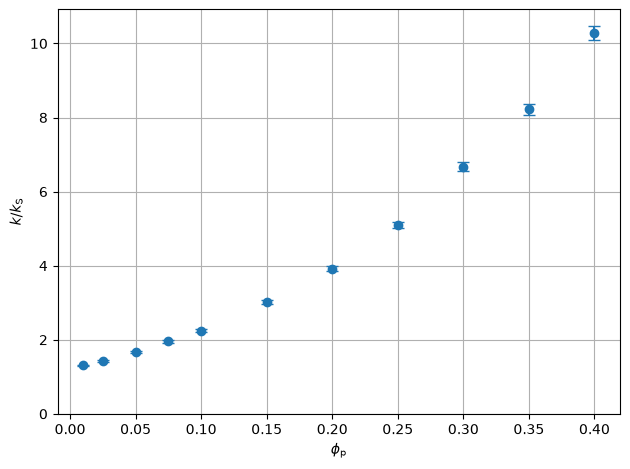

In [16]:
_ = plot_collision_rate(result_monomodal)

### Bimodal System: Effect of $r_i/r_j$

In [17]:
def compute_alpha(data: dict) -> NDArray:
    """
    Compute the exponent alpha.

    Parameters
    ----------
    data : dict
        Dictionary containing the results of the simulations, including the volume
        fractions and the times of successful walks.

    Returns
    -------
    NDArray
        Array of alpha values corresponding to the total volume fractions.
    """
    rs = data["inputs"]["rs"]
    if len(rs) != 2:
        raise ValueError("Expected exactly two particle types for alpha calculation.")

    results = data["results"]
    alpha = np.zeros(len(results))
    for i, d in enumerate(results):
        walks = d["walks"]
        groups = [walk["particle_group"] for walk in walks if walk["success"]]
        counts = [groups.count(k) for k in range(len(rs))]
        vfs = d["vfs"]
        alpha[i] = 3.0 + np.log(counts[0] / counts[1] * vfs[1] / vfs[0]) / np.log(
            rs[0] / rs[1]
        )

    return alpha

In [18]:
def plot_alpha(data: list[dict] | dict):
    """
    Plot alpha for a bimodal distribution as a function of the total volume fraction of
    the particles.

    Parameters
    ----------
    data : list[dict] | dict
        List of dictionaries containing the results of the simulations, including the
        volume fractions and the times of successful walks.

    Returns
    -------
    matplotlib.figure.Figure
        The figure containing the plot.
    """
    fig, ax = plt.subplots()

    if isinstance(data, dict):
        data = [data]

    for d in data:
        vfp = d["inputs"]["vfp"]
        rs = d["inputs"]["rs"]
        ns = d["inputs"]["ns"]
        alpha = compute_alpha(d)
        label = r"$r_1/r_2=$" f"{rs[0]/rs[1]:.1f}, " r"$n_1/n_2=$" f"{ns[0]/ns[1]:.2f}"
        ax.scatter(vfp, alpha, label=label)

    ax.set_xlabel(r"$\phi_\mathrm{p}$")
    ax.set_ylabel(r"$\alpha$")
    ax.grid(True)
    ax.legend(loc="upper left")
    fig.tight_layout()

    return fig

In [19]:
vfp = [0.001, 0.01, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.4]
number_particles_per_box = 2000
number_boxes = 20
number_walks_per_box = 4000

In [20]:
result_bimodal_21_11 = simulate_dispersion(
    rs=[2.0, 1.0],
    ns=[1.0, 1.0],
    vfp=vfp,
    number_particles_per_box=number_particles_per_box,
    number_boxes=number_boxes,
    number_walks_per_box=number_walks_per_box,
)

Volume fraction: 0.001
Volume fraction: 0.010
Volume fraction: 0.050
Volume fraction: 0.100
Volume fraction: 0.150
Volume fraction: 0.200
Volume fraction: 0.250
Volume fraction: 0.300
Volume fraction: 0.350
Volume fraction: 0.400
Saving results to simulation_20260626_205633.pkl... Done!


In [21]:
result_bimodal_21_12 = simulate_dispersion(
    rs=[2.0, 1.0],
    ns=[1.0, 2.0],
    vfp=vfp,
    number_particles_per_box=number_particles_per_box,
    number_boxes=number_boxes,
    number_walks_per_box=number_walks_per_box,
)

Volume fraction: 0.001
Volume fraction: 0.010
Volume fraction: 0.050
Volume fraction: 0.100
Volume fraction: 0.150
Volume fraction: 0.200
Volume fraction: 0.250
Volume fraction: 0.300
Volume fraction: 0.350
Volume fraction: 0.400
Saving results to simulation_20260626_205658.pkl... Done!


In [22]:
result_bimodal_41_11 = simulate_dispersion(
    rs=[4.0, 1.0],
    ns=[1.0, 1.0],
    vfp=vfp,
    number_particles_per_box=number_particles_per_box,
    number_boxes=number_boxes,
    number_walks_per_box=number_walks_per_box,
)

Volume fraction: 0.001
Volume fraction: 0.010
Volume fraction: 0.050
Volume fraction: 0.100
Volume fraction: 0.150
Volume fraction: 0.200
Volume fraction: 0.250
Volume fraction: 0.300
Volume fraction: 0.350
Volume fraction: 0.400
Saving results to simulation_20260626_205728.pkl... Done!


In [23]:
result_bimodal_41_14 = simulate_dispersion(
    rs=[4.0, 1.0],
    ns=[1.0, 4.0],
    vfp=vfp,
    number_particles_per_box=number_particles_per_box,
    number_boxes=number_boxes,
    number_walks_per_box=number_walks_per_box,
)

Volume fraction: 0.001
Volume fraction: 0.010
Volume fraction: 0.050
Volume fraction: 0.100
Volume fraction: 0.150
Volume fraction: 0.200
Volume fraction: 0.250
Volume fraction: 0.300
Volume fraction: 0.350
Volume fraction: 0.400
Saving results to simulation_20260626_205754.pkl... Done!


In [24]:
result_bimodal_81_11 = simulate_dispersion(
    rs=[8.0, 1.0],
    ns=[1.0, 1.0],
    vfp=vfp,
    number_particles_per_box=number_particles_per_box,
    number_boxes=number_boxes,
    number_walks_per_box=number_walks_per_box,
)

Volume fraction: 0.001
Volume fraction: 0.010
Volume fraction: 0.050
Volume fraction: 0.100
Volume fraction: 0.150
Volume fraction: 0.200
Volume fraction: 0.250
Volume fraction: 0.300
Volume fraction: 0.350
Volume fraction: 0.400
Saving results to simulation_20260626_205825.pkl... Done!


In [25]:
result_bimodal_81_18 = simulate_dispersion(
    rs=[8.0, 1.0],
    ns=[1.0, 8.0],
    vfp=vfp,
    number_particles_per_box=number_particles_per_box,
    number_boxes=number_boxes,
    number_walks_per_box=number_walks_per_box,
)

Volume fraction: 0.001
Volume fraction: 0.010
Volume fraction: 0.050
Volume fraction: 0.100
Volume fraction: 0.150
Volume fraction: 0.200
Volume fraction: 0.250
Volume fraction: 0.300
Volume fraction: 0.350
Volume fraction: 0.400
Saving results to simulation_20260626_205900.pkl... Done!


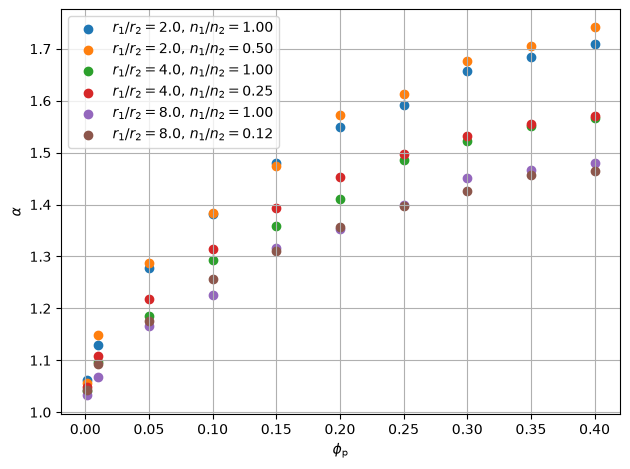

In [26]:
_ = plot_alpha(
    [
        result_bimodal_21_11,
        result_bimodal_21_12,
        result_bimodal_41_11,
        result_bimodal_41_14,
        result_bimodal_81_11,
        result_bimodal_81_18,
    ]
)